# ChestXRay Diagnosis Tool — Module B: Grad-CAM Explainability

Runs **locally on your laptop** (no GPU required, no internet after install).

For each X-ray image, this notebook produces:
- Disease probabilities for Cardiomegaly, Effusion, and Pneumothorax
- 3 Grad-CAM heatmaps overlaid on the original X-ray — one per disease

**Color scale:** Blue (low attention) → Red (high attention)

---
### Before running
1. Install dependencies (run once in your terminal):
   ```bash
   pip install torch torchvision pytorch-grad-cam opencv-python matplotlib Pillow
   ```
2. Set `MODEL_PATH` and `IMAGE_PATH` in **Step 2** below.

## Step 1 — Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from PIL import Image
from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print('All imports OK.')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU (your laptop)"}')

All imports OK.
PyTorch version: 2.2.2
Device: CPU (your laptop)


## Step 2 — Configuration

**Edit these two paths before running anything else.**

In [9]:
# -------------------------------------------------------
# EDIT THESE TWO PATHS
# -------------------------------------------------------

# Path to your downloaded best_model.pth
MODEL_PATH = 'models/best_model.pth'

# Path to any chest X-ray .png you want to analyse
IMAGE_PATH = 'test/00000001_000.png'

# Output folder — heatmaps will be saved here
OUTPUT_DIR = Path('./gradcam_outputs')

# -------------------------------------------------------
# These must match training exactly — do NOT change
# -------------------------------------------------------
TARGET_DISEASES = ['Cardiomegaly', 'Effusion', 'Pneumothorax']
NUM_CLASSES     = len(TARGET_DISEASES)
IMAGE_SIZE      = 224
THRESHOLD       = 0.5   # Sigmoid threshold for positive prediction

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model  : {MODEL_PATH}')
print(f'Image  : {IMAGE_PATH}')
print(f'Output : {OUTPUT_DIR.resolve()}')
print(f'Device : {DEVICE}')

# Quick sanity check
assert Path(MODEL_PATH).exists(), f'ERROR: Model file not found at {MODEL_PATH}'
assert Path(IMAGE_PATH).exists(), f'ERROR: Image file not found at {IMAGE_PATH}'
print('\nPaths verified OK.')

Model  : models/best_model.pth
Image  : test/00000001_000.png
Output : /Users/aryanvarshney/Downloads/Medical-Diagnosis-Tools/ChestXRay-Diagnosis-Tool/backend/gradcam_outputs
Device : cpu

Paths verified OK.


## Step 3 — Load the Trained Model

Rebuilds the exact same DenseNet-121 architecture used during training, then loads your saved weights.

In [10]:
# Rebuild the same architecture as training (must match exactly)
model = models.densenet121(weights=None)  # No ImageNet weights — we load our own

# Freeze all layers (matches training setup)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze denseblock4 + norm5 (matches training setup)
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Replace classifier head (matches training setup)
num_features = model.classifier.in_features  # 1024 for DenseNet-121
model.classifier = nn.Linear(num_features, NUM_CLASSES)

# Load trained weights from your .pth file
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()  # IMPORTANT: switch to eval mode

print(f'Model loaded from epoch   : {checkpoint["epoch"]}')
print(f'Best val loss             : {checkpoint["val_loss"]:.4f}')
print('Val AUC-ROC per disease:')
for disease, auc in checkpoint['val_aucs'].items():
    print(f'  {disease:<15}: {auc:.4f}')

Model loaded from epoch   : 3
Best val loss             : 0.3299
Val AUC-ROC per disease:
  Cardiomegaly   : 0.8250
  Effusion       : 0.7996
  Pneumothorax   : 0.7499


## Step 4 — Load & Preprocess the X-Ray Image

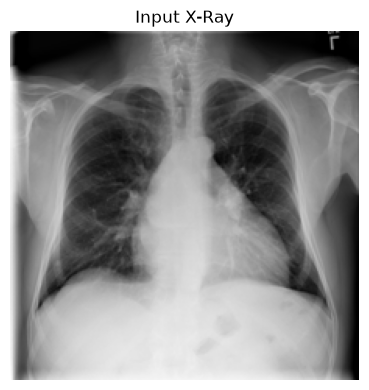

Image loaded: 00000001_000.png
Input tensor shape: torch.Size([1, 3, 224, 224])


In [11]:
# Same eval transforms as during training
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load image
pil_img = Image.open(IMAGE_PATH)
if pil_img.mode != 'RGB':
    pil_img = pil_img.convert('RGB')

# For heatmap overlay: resized to 224x224, values in [0, 1]
pil_resized = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE))
rgb_img = np.array(pil_resized, dtype=np.float32) / 255.0

# For the model: normalised tensor [1, 3, 224, 224]
input_tensor = eval_transforms(pil_img).unsqueeze(0).to(DEVICE)

# Show the original image
plt.figure(figsize=(4, 4))
plt.imshow(rgb_img, cmap='gray')
plt.title('Input X-Ray', color='black', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image loaded: {Path(IMAGE_PATH).name}')
print(f'Input tensor shape: {input_tensor.shape}')  # [1, 3, 224, 224]

## Step 5 — Run Inference (Disease Probabilities)

In [12]:
with torch.no_grad():
    logits = model(input_tensor)                     # [1, 3] raw logits
    probs  = torch.sigmoid(logits).cpu().numpy()[0]  # [3]   probabilities

print('=' * 50)
print('  DISEASE PROBABILITIES')
print('=' * 50)
for disease, prob in zip(TARGET_DISEASES, probs):
    status = 'POSITIVE ✅' if prob >= THRESHOLD else 'Negative  '
    bar    = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
    print(f'  {disease:<15} {bar}  {prob*100:5.1f}%  {status}')
print('=' * 50)

  DISEASE PROBABILITIES
  Cardiomegaly    ███████████████░░░░░   76.6%  POSITIVE ✅
  Effusion        ██████░░░░░░░░░░░░░░   30.5%  Negative  
  Pneumothorax    █░░░░░░░░░░░░░░░░░░░    8.1%  Negative  


## Step 6 — Generate Grad-CAM Heatmaps

Attaches Grad-CAM to `model.features.denseblock4` — the last convolutional block of DenseNet-121.  
Generates a **separate heatmap per disease** showing exactly where the model looked for each condition.

In [13]:
target_layers = [model.features.denseblock4]

heatmaps = {}

for disease_idx, disease_name in enumerate(TARGET_DISEASES):
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(disease_idx)]

    # grayscale_cam: [1, H, W] — activation values in [0, 1]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # [H, W]

    # Overlay heatmap on the original X-ray
    cam_image = show_cam_on_image(
        img=rgb_img,
        mask=grayscale_cam,
        use_rgb=True,
        colormap=cv2.COLORMAP_JET
    )

    heatmaps[disease_name] = {
        'overlay':   cam_image,       # RGB uint8 [224, 224, 3]
        'grayscale': grayscale_cam,   # Raw float [224, 224]
        'prob':      probs[disease_idx]
    }
    print(f'  Generated heatmap for {disease_name} (prob={probs[disease_idx]*100:.1f}%)')

print('\nAll heatmaps generated.')

  Generated heatmap for Cardiomegaly (prob=76.6%)
  Generated heatmap for Effusion (prob=30.5%)
  Generated heatmap for Pneumothorax (prob=8.1%)

All heatmaps generated.


## Step 7 — Display Results

/var/folders/q3/s471syz94rgcsb8kr4w7vbg80000gn/T/ipykernel_12123/3055642623.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


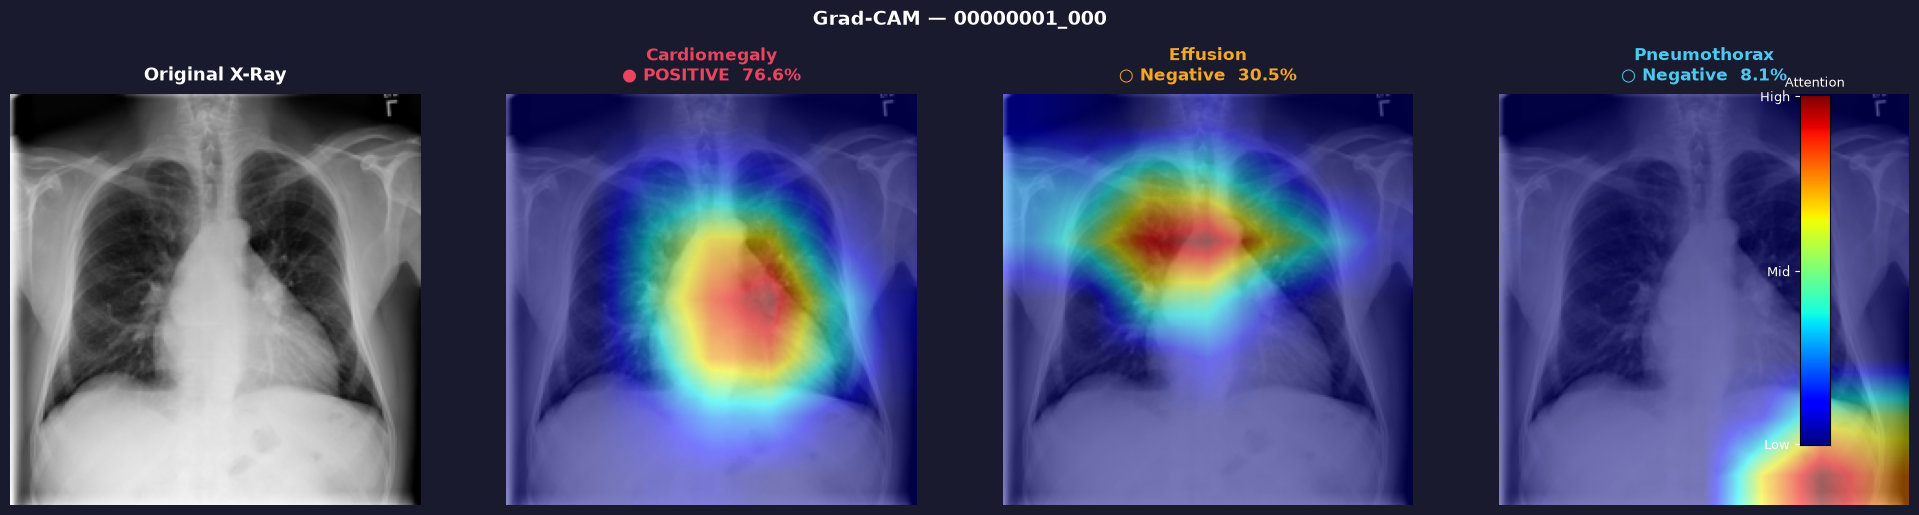

Saved: /Users/aryanvarshney/Downloads/Medical-Diagnosis-Tools/ChestXRay-Diagnosis-Tool/backend/gradcam_outputs/00000001_000_gradcam.png


In [7]:
disease_colors = {
    'Cardiomegaly': '#e94560',
    'Effusion':     '#f5a623',
    'Pneumothorax': '#4cc9f0',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#1a1a2e')

# Panel 0: original
axes[0].imshow(rgb_img, cmap='gray')
axes[0].set_title('Original X-Ray', color='white', fontsize=13,
                   fontweight='bold', pad=10)
axes[0].axis('off')

# Panels 1-3: heatmaps
for ax, disease_name in zip(axes[1:], TARGET_DISEASES):
    data  = heatmaps[disease_name]
    prob  = data['prob']
    color = disease_colors[disease_name]
    positive = prob >= THRESHOLD

    ax.imshow(data['overlay'])

    status_text  = f'● POSITIVE  {prob*100:.1f}%' if positive else f'○ Negative  {prob*100:.1f}%'
    status_color = '#00ff88' if positive else '#aaaaaa'

    ax.set_title(f'{disease_name}\n{status_text}',
                 color=color, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

    # Coloured border — bright if positive, grey if negative
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color if positive else '#444444')
        spine.set_linewidth(3)

# Colour bar (attention legend)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
gradient = np.linspace(0, 1, 256).reshape(256, 1)
cbar_ax.imshow(gradient[::-1], aspect='auto', cmap='jet')
cbar_ax.set_xticks([])
cbar_ax.set_yticks([0, 128, 255])
cbar_ax.set_yticklabels(['High', 'Mid', 'Low'], color='white', fontsize=9)
cbar_ax.set_title('Attention', color='white', fontsize=9)
cbar_ax.tick_params(colors='white')

image_name = Path(IMAGE_PATH).stem
plt.suptitle(f'Grad-CAM — {image_name}',
             color='white', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()

# Save to output folder
out_path = OUTPUT_DIR / f'{image_name}_gradcam.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Saved: {out_path.resolve()}')

## Step 8 — (Optional) Analyse Multiple Images in a Folder

Set `BATCH_DIR` to any folder of `.png` X-rays. Results are saved to `gradcam_outputs/`.

In [8]:
# ---- Set the folder containing your X-ray images ----
BATCH_DIR  = Path('/Users/aryanvarshney/Downloads/xrays')
MAX_IMAGES = 10   # Set to None to process all

target_layers = [model.features.denseblock4]

image_files = sorted(BATCH_DIR.glob('*.png'))
if MAX_IMAGES:
    image_files = image_files[:MAX_IMAGES]

print(f'Processing {len(image_files)} images from {BATCH_DIR}...\n')

for i, img_path in enumerate(image_files):
    try:
        # Load image
        pil = Image.open(img_path)
        if pil.mode != 'RGB':
            pil = pil.convert('RGB')
        rgb = np.array(pil.resize((IMAGE_SIZE, IMAGE_SIZE)), dtype=np.float32) / 255.0
        tensor = eval_transforms(pil).unsqueeze(0).to(DEVICE)

        # Inference
        with torch.no_grad():
            p = torch.sigmoid(model(tensor)).cpu().numpy()[0]

        # Plot
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.patch.set_facecolor('#1a1a2e')
        axes[0].imshow(rgb, cmap='gray')
        axes[0].set_title('Original', color='white')
        axes[0].axis('off')

        for ax, (didx, dname) in zip(axes[1:], enumerate(TARGET_DISEASES)):
            cam = GradCAM(model=model, target_layers=target_layers)
            gcam = cam(input_tensor=tensor,
                       targets=[ClassifierOutputTarget(didx)])[0]
            overlay = show_cam_on_image(rgb, gcam, use_rgb=True,
                                        colormap=cv2.COLORMAP_JET)
            ax.imshow(overlay)
            status = '✅' if p[didx] >= THRESHOLD else '○'
            ax.set_title(f'{dname}\n{status} {p[didx]*100:.1f}%', color='white')
            ax.axis('off')

        out = OUTPUT_DIR / f'{img_path.stem}_gradcam.png'
        plt.tight_layout()
        plt.savefig(out, dpi=100, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.close()
        print(f'[{i+1}/{len(image_files)}] {img_path.name} -> saved')

    except Exception as e:
        print(f'[{i+1}] Skipped {img_path.name}: {e}')

print(f'\nDone. All outputs saved to: {OUTPUT_DIR.resolve()}')

Processing 0 images from /Users/aryanvarshney/Downloads/xrays...


Done. All outputs saved to: /Users/aryanvarshney/Downloads/Medical-Diagnosis-Tools/ChestXRay-Diagnosis-Tool/backend/gradcam_outputs
